<a href="https://colab.research.google.com/github/Simon-Olarte/telecom-analysis-Sprint7-proyect/blob/main/S7_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print('------------------------------')
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
------------------------------
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print('------------------------------')
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
------------------------------
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y qué acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Diagnóstico y pasos a seguir**
En el dataset **users** hay varias columnas con valores nulos o  faltantes:
estas son:
**'city'** con **469** valores faltantes equivalentes al **12%**. --> revisar a mayor detalle para decidir si imputarlos o mantenerlos como nulos.
**'churn_date'** con **3534** valores faltantes equivalentes a más del **88%**. --> ignorar o eliminar(al momento de exportar o unir los database no se siente en cuenta como columna relevante )
En el dataset **usage** hay varias columnas con valores nulos o faltantes:
estas son:

**'date'** con **50** valores faltantes equivalentes al **0.1%**.--> verificar a detalle con el fin de saber si vale la pena su imputación o mantenerlos como nulos.
**'duration'** con **22076** valores faltantes equivalentes a más del **55%**.-->  diagnosticar el tipo de valor faltante si es MAR o MNAR para decidir si se deben eliminar, mantener o capa

**'length'** con **17896** valores faltantes equivalentes a más del **44%**.--> diagnosticar el tipo de valor faltante si es MAR o MNAR para decidir si se deben eliminar, mantener o capar.



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` se encuentra en formato numérico, pero es una columna categórica ya que son identificadores únicos que no se utilizan para realizar cálculos.
- La columna `age` contiene el valor inválido -999 usualmente utilizado como sentinel, se debe profundizar en las filas en las cuales la edad es este valor. Valor que distorsiona el valor de la media, se debe tener en cuenta en el futuro para evitar sesgos erroneos.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` están en formato numérico, pero son columnas categóricas, ya que son identificaciones únicas que no se utilizan para realizar cálculos.
- las columnas `duration` y `length` cuentan con 22076 y 17896 valores nulos o faltantes respectivamente.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())

print('------------------------------')

print(users[columnas_user].value_counts())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595
------------------------------
city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64


- La columna `city` cuenta con valores faltantes o nulos, con 7 categorías diferentes de las cuales la moda es Bogotá, que representa 808 de los 3531 valores. También se evidencia la existencia de una categoría `?` y otra que se muestra en blanco. Estas categorías que no corresponden a nombres de ciudades deberán ser revisadas a profundidad para decidir cómo se manejarán.
- La columna `plan` no cuenta con valores nulos o faltantes, solo hay 2 tipos de plan y la moda es el plan Básico que representa 2595 de los 4000 valores. Sin embargo, se debe revisar las filas que cuentan con un valor en la columna plan pero no cuentan con valor de ciudad.

In [ ]:
# explorar columna categórica de usage
print(usage['type'].describe())

print('------------------------------')

print(usage['type'].value_counts())


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object
------------------------------
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` no tiene valores nulos, solo hay 2 tipos de uso únicos `text` y `call`, entre los cuales la moda es text que representa 22092 de los 40000 valores totales.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?
Al explorar las columnas categóricas de cada dataset se encontró lo siguiente:

**users**
En la columna `city`, hay un total de 469 valores faltantes, y sentinels como `?` y `  ` que deberán revisarse a profundidad para analizar qué patrones se encuentran y cómo se deben manejar estas filas, si se deben mantener o eliminar.
**usage**
En la columna `type` no se hallaron valores faltantes o sentinels a tener en cuenta.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = 'coerce')


print(users.info())

print('------------------------------')

print(users['reg_date'].dt.year.value_counts())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB
None
------------------------------
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = 'coerce')

print(usage.info())

print('------------------------------')

print(usage['date'].dt.year.value_counts())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB
None
------------------------------
2024.0    39950
Name: date, dtype: int64


In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.unique())

[2022 2026 2023 2024]


En `reg_date`, hay datos correspondientes a el año 2026 lo que es imposible, ya que las bases de datos solo van hasta el año 2024. Los datos con años imposibles se deben analizar para decidir como se van a a tratar.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.unique())

[2024.   nan]


En `date`, solo hay datos para el año 2024 y valores nulos. Para el análisis conjunto solo utilizaremos el año 2024.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Se encontraron valores imposibles en la columna `reg_date`, correspondientes al año 2026, al ser fechas imposibles e inválidas para el análisis de los datos, estos se van a reemplazar por nulos para evitar cualquier tipo de confusión.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024 , 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage[usage['duration'].isna()].groupby('type').size()

type
text    22076
dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage[usage['length'].isna()].groupby('type').size()

type
call    17896
dtype: int64

Haz doble clic aquí y escribe que tu diagnóstico de nulos en `duration` y `length`

Luego de agrupar los valores nulos de las columnas `duration` y `length` en relación a la columna `type` se logra evidenciar claramente que estos son valores MAR ya que luego de la agrupación se hace evidente que son variables categóricas relacionadas, los valores de la columna `duration` son únicamente para el `type` call y los de la columna `length` para text. lo que significa que hay una razón valida para que sean nulos, y  teniendo esto en cuenta, se deben mantener como tal, ya que si se eliminaran las filas con los valores nulos de ambas columnas basicamente estariamos eliminando todo el dataset.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text':'sum','is_call':'sum','duration':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns = {'is_text':'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
users_short = users[['user_id','first_name','last_name','age','city','reg_date','plan']]
user_profile = pd.merge(usage_agg, users_short, on= 'user_id', how = 'inner')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[['cant_mensajes','cant_llamadas','cant_minutos_llamada','age']].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.124531
std,2.358416,2.144238,18.168095,17.692032
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,47.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
print((user_profile['plan'].value_counts(normalize = True))*100)


Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

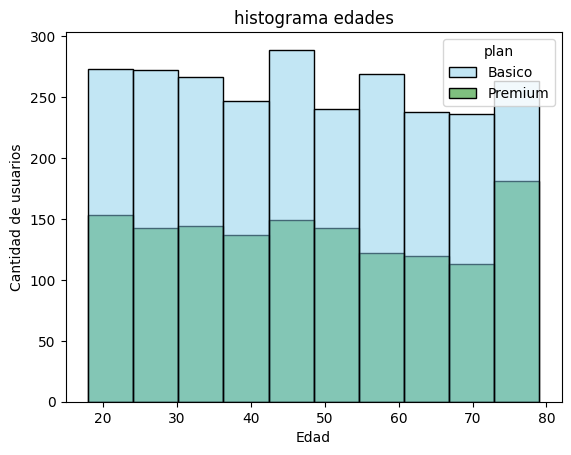

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data= user_profile, x= user_profile['age'],hue= 'plan', bins = 10,palette=['skyblue','green'])
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('histograma edades')
plt.show()

💡Insights:
- Distribución normal, aunque hay algunos picos, no se evidencia ningún tipo de sesgo, y esto se debe a que las personas de cualquier edad pueden hacer uso de un plan de mensajes y llamadas.

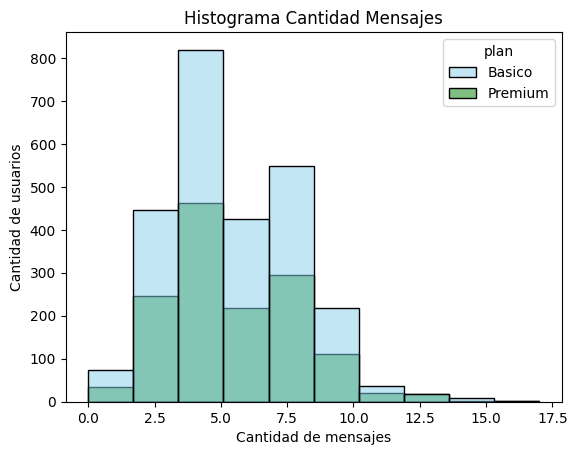

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data= user_profile, x= user_profile['cant_mensajes'],hue= 'plan', bins = 10,palette=['skyblue','green'])
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Histograma Cantidad Mensajes')
plt.show()

💡Insights:
- Distribución con un pequeño sesgo a la derecha, como se puede evidenciar en el grafico hay unos pocos ususarios que hacen un mayor uso de sus mensajes, esto es normal y se puede explicar gracias a que en este tipo de mercado el uso de el plan depende unicamente de las necesidades del usuario, y aunque la mayoria tienda a hacer un uso moderado de los mensajes hay perfiles de usuario que requieren enviar mensajes mas seguido.

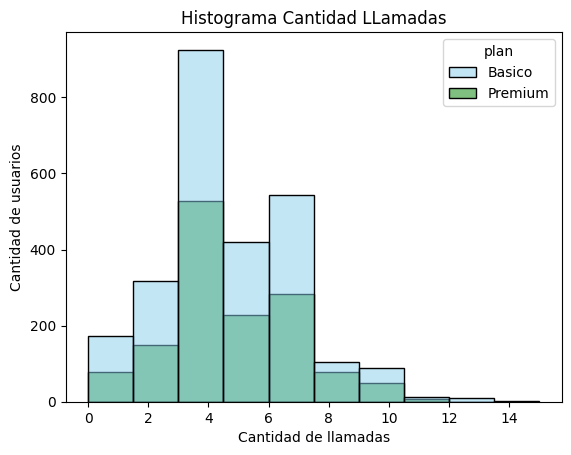

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data= user_profile, x= user_profile['cant_llamadas'],hue= 'plan', bins = 10,palette=['skyblue','green'])
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Histograma Cantidad LLamadas')
plt.show()


💡Insights:
- Distribución con un pequeño sesgo a la derecha, en este caso teniendo en cuenta el tipo de mercado y que los valores altos son razonables ya que cada usuario puede hacer uso de sus llamadas como lo necesite.

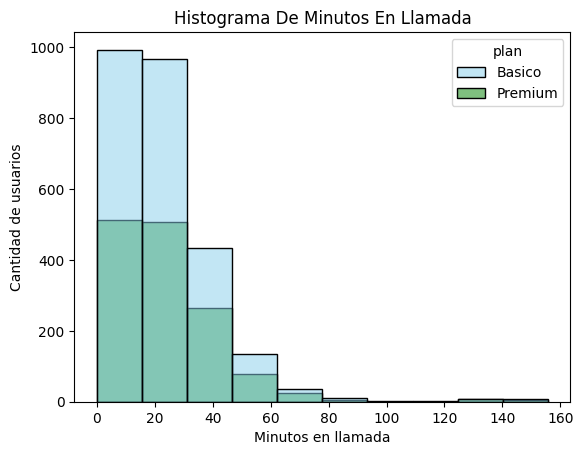

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= user_profile, x= user_profile['cant_minutos_llamada'],hue= 'plan', bins = 10,palette=['skyblue','green'])
plt.xlabel('Minutos en llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Histograma De Minutos En Llamada')
plt.show()


💡Insights:
- Los datos tienen una distribución con sesgo a la derecha, como se puede evidenciar en el gráfico, ya que se evidencia que aunque pocos hay algunos usuarios que duran mucho más minutos en llamada que la media, es por esto que el promedio deja de ser un valor objetivo y en dado caso de necesitarse es más representativo el valor de la media. Este sesgo es lógico del mercado ya que el uso del tiempo en llamada es dependiente únicamente del cliente, si un cliente usa su plan para tener reuniones de negocio, evidentemente va a tener un tiempo mayor en llamada que uno que simplemente lo utiliza para hablar con su pareja.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

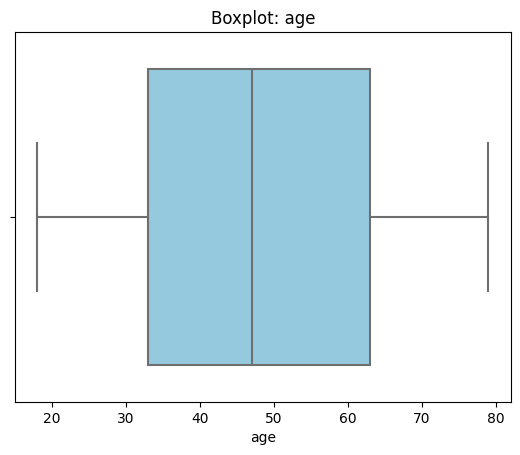

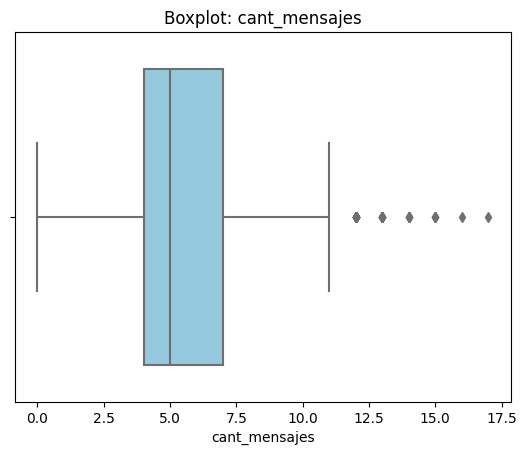

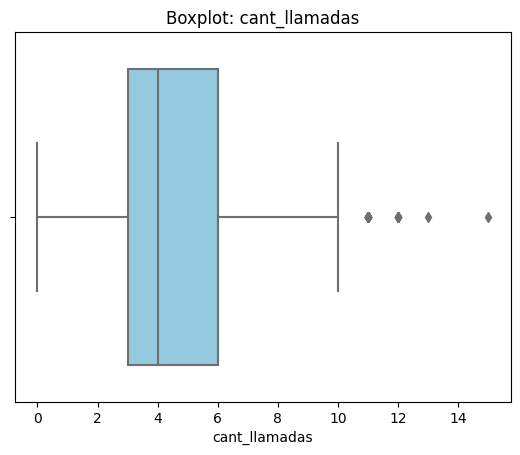

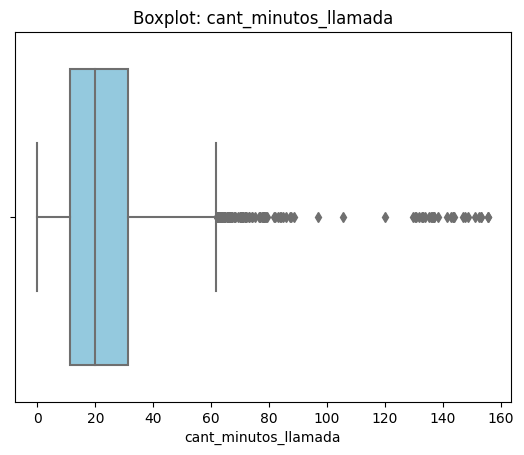

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col],color = 'skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: Luego de la limpieza y el proceso en el que se remplazaron los sentinels(-999) con la mediana ya no existe ningún valor atípico en los datos.
- cant_mensajes: Al analizar el gráfico, se observan un par de valores atípicamente altos, pero teniendo en cuenta que esto solo corresponde al uso del usuario, la existencia de estos valores atípicos es inherente al tipo de variable y del mercado y se deben mantener en la base de datos ya que nos permiten saber qué usuarios hacen un uso alto de sus mensajes.
- cant_llamadas: Al analizar el gráfico, se observan un par de valores atípicamente altos, pero teniendo en cuenta que esto solo corresponde al uso del usuario, la existencia de estos valores atípicos es inherente al tipo de variable y del mercado y se deben mantener en la base de datos ya que nos permiten saber qué usuarios hacen un uso alto de sus LLamadas.
- cant_minutos_llamada: Al analizar el gráfico, se observan un par de valores atípicamente altos, pero teniendo en cuenta que esto solo corresponde al uso del usuario, la existencia de estos valores atípicos es inherente al tipo de variable y del mercado y se deben mantener en la base de datos ya que nos permiten saber qué usuarios hacen un uso alto de sus mensajes.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR= Q3 - Q1
    lower= Q1 - 1.5*(IQR)
    upper= Q3 + 1.5*(IQR)
    print(f"Columna: {col} | Límite inferior: {lower} | Límite superior: {upper}")



Columna: age | Límite inferior: -12.0 | Límite superior: 108.0
Columna: cant_mensajes | Límite inferior: -0.5 | Límite superior: 11.5
Columna: cant_llamadas | Límite inferior: -1.5 | Límite superior: 10.5
Columna: cant_minutos_llamada | Límite inferior: -19.322500000000005 | Límite superior: 61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?



En este caso, como los valores de cada de una de estas columnas es dependiente unicamente del uso que los usuarios le dan a su plan todos los valores atipicos o outliers se deben mantener ya que nos dan informacion real sobre que hace cada usuario con su plan, y nos permite segmentarlos en diferentes grupos, por ejemplo si hay un valor muy alto tanto de cant_mensajes, cant_llamadas o cant_minutos_llamada, esto solo significa que el usuario usa su plan mas que el comun de los usuarios, lo que le permitiria a la empresa categorizarlo como usuario de alto uso y hacer ofertas para este tipo de clientes.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
condiciones_uso = [(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
              (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
              (user_profile['cant_llamadas'] >= 10 ) & (user_profile['cant_mensajes'] >= 10)]
resultados_uso = ['Bajo uso', 'Uso medio', 'Alto uso']

user_profile['grupo_uso'] = np.select(condiciones_uso,resultados_uso, default = 'desconocido')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,desconocido
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,desconocido
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
condiciones_edad = [(user_profile['age'] < 30),(user_profile['age']<60),(user_profile['age']>=60)]
resultados_edad = ['Joven','Adulto','Adulto Mayor']

user_profile['grupo_edad'] = np.select(condiciones_edad,resultados_edad,default='desconocido')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,desconocido,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,desconocido,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

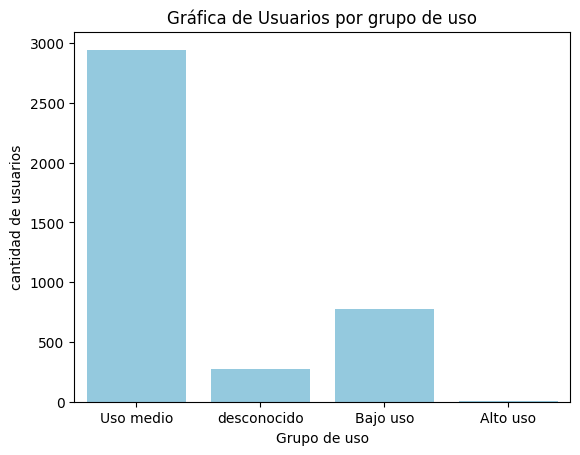

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x = user_profile['grupo_uso'], color = 'skyblue')
plt.xlabel('Grupo de uso')
plt.ylabel('cantidad de usuarios')
plt.title('Gráfica de Usuarios por grupo de uso')
plt.show()

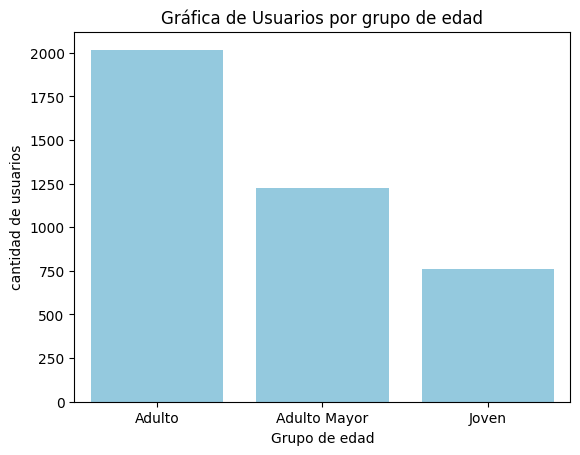

In [ ]:
# Visualización de los segmentos por edad
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x = user_profile['grupo_edad'], color = 'skyblue')
plt.xlabel('Grupo de edad')
plt.ylabel('cantidad de usuarios')
plt.title('Gráfica de Usuarios por grupo de edad')
plt.show()

In [ ]:
print (user_profile['grupo_uso'].value_counts())

print('----------------------------------------------------')

print(user_profile['grupo_edad'].value_counts())

print('----------------------------------------------------')

print(pd.crosstab(user_profile['grupo_edad'], user_profile['grupo_uso']))

user_profile.to_csv('user_profile_limpio.csv', index=False)


Uso medio      2943
Bajo uso        778
desconocido     274
Alto uso          4
Name: grupo_uso, dtype: int64
----------------------------------------------------
Adulto          2017
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64
----------------------------------------------------
grupo_uso     Alto uso  Bajo uso  Uso medio  desconocido
grupo_edad                                              
Adulto               0       364       1500          153
Adulto Mayor         2       257        891           72
Joven                2       157        552           49



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Datos faltantes y columnas con porcentajes altos de valores nulos.

En las bases de datos originales, encontramos múltiples columnas con porcentajes altos de valores nulos, inicialmente parecia que esto podia afectar el analisis, pero al investigar mas a fondo encontramos que algunas de ellas eran irrelevantes para nuestros propositos `chrug_date` y las otras `duration` y `length` cuyos valores faltantes parecian podian afectar el analisis, terminaron siendo gran parte de el ya que correspondian a valores MAR lo que significa que su ausencia se relaciona directamente con la informacion de otra columna, en este caso  con la informacion de la columna `type`
  
Por otro lado, se encontraron columnas cuyo tipo de datos era incorrecto pero que luego de un pequeño proceso de limpieza se lograron estandarizar al tipo correcto, lo que nos permitió realizar las revisiones y cálculos necesarios para entender el porqué de los datos.

Además de tipos incorrectos, también se halló la presencia de sentinelas y valores imposibles que luego fueron reemplazados por la mediana en el caso de la columna `edad` o por valores nulos en las columnas `city` y `reg_date` con el fin de facilitar el manejo de los datos y evitar errores en los análisis.


🔍 **Segmentos por Edad**

- Se segmentaron los usuarios por grupos de edad, Jóvenes todos los usuarios menores a 30 años, Adultos los usuarios mayores a 30 años pero menores de 60 y adultos mayores todos aquellos usuarios mayores de 60 años. la segmentacion por edades nos permite entender los comportamientos de consumo de los usuarios dentro de cada uno de estos grupos de edad, lo que le permitira a la empresa segmentar sus campañas de mercadeo de forma mas acertada para cada uno de estos grupos o incluso de analizar las posibilidades de lanzar al mercado nuevos planes especializados basados en las necesidades de los usuarios según sus edades.

📊 **Segmentos por Nivel de Uso**
- Se segmentaron los usuarios en diferentes niveles de uso basados en su consumo del plan tanto como de llamadas como de mensajes en los siguientes niveles, bajo uso para los usuarios con un consumo de menos de 5 mensajes y 5 llamadas, uso medio para usuarios con más de 5 pero menos de 10 llamadas y 10 mensajes, alto uso para usuarios con 10 o más llamadas y 10 o más mensajes y por ultimo una categoria llamada desconocido, que debido a la incosistencia entre el uso de llamadas y mensajes no entra dentro de ninguno de los niveles de consumo, con respecto a esta ultima se recomienda verificar la posibilidad de ofertar a este segmento planes que incluyan o que tengan en cuenta su consumo, es decir si solo se hace uso de las llamadas o de los mensajes, se pueden ofrecer categorias dentro de los mismos tipos de plan entre basico y premium que se ajusten unicamente a su necesidad en especifico.

¿Qué segmentos muestran mayor o menor uso?


El 74% de los usuarios está en "uso medio" y apenas 4 personas califican como "alto uso" — prácticamente nadie está consumiendo al tope. El plan Básico y Premium tienen consumos casi idénticos (5.5 mensajes, 4.5 llamadas), lo que sugiere que el plan Premium no está generando mayor consumo real.

¿Qué usuarios presentan valores atípicos que puedan indicar comportamientos inusuales, fraude o errores de registro?

Los minutos son la anomalía dominante. 109 usuarios superan el límite de 61.9 minutos, y los más extremos llegan a 155 min. Lo interesante es que muchos de ellos tienen llamadas y mensajes completamente normales — son usuarios que hacen pocas llamadas pero muy largas

Los adultos mayores aparecen fuertemente en los outliers por minutos, lo que refuerza la recomendación de diseñar un plan orientado a llamadas largas para ese segmento.

¿Cómo varía el uso según edad y plan?
La variación es mínima entre grupos de edad, lo cual es sorprendente. Los adultos mayores con Premium tienen los minutos medianos más altos (21.1 min), pero la diferencia no es dramática. Los jóvenes son el grupo más pequeño (19%) y tienen el consumo más bajo en llamadas, lo que los hace un segmento con potencial de crecimiento.

¿Qué patrones sirven para diseñar mejores planes?
Tres señales concretas: (1) el segmento "desconocido" (274 usuarios) tiene un promedio de mensajes de 9.5 vs 5.1 del resto — son usuarios de alto valor sin clasificar, prioritarios para retención; (2) el plan Premium no diferencia el comportamiento, lo que sugiere que los incentivos o beneficios no son percibidos; (3) la demanda de minutos de llamada es bastante consistente entre todos los segmentos, lo que apunta a que un plan con minutos ilimitados o paquetes de llamadas tendría buena acogida transversal.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`